# Notebook 7 — Profitability Analysis
**Purpose:** Quantify ApexMart's profitability drivers at a granular level and
build a simple explanatory model of what predicts transaction-level margin.

**Libraries used:** `pandas`, `numpy`, `matplotlib`, `scikit-learn`


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

DATA_DIR = "../01_Data"
sales = pd.read_csv(f"{DATA_DIR}/sales_clean.csv", parse_dates=["Transaction_Date"])
products = pd.read_csv(f"{DATA_DIR}/products.csv")
stores = pd.read_csv(f"{DATA_DIR}/stores.csv")

df = sales.merge(products[['Product_ID','Category']], on='Product_ID', how='left')
df = df.merge(stores[['Store_ID','Region']], on='Store_ID', how='left')
df = df[df['Sales_Amount'] > 0].copy()
df['Margin_Pct'] = 100 * df['Profit'] / df['Sales_Amount']
df['Discount_Pct'] = df['Discount'] / (df['Unit_Price']*df['Quantity_Sold']).replace(0, np.nan)
df = df.dropna(subset=['Margin_Pct','Discount_Pct'])
print(f"Modelling dataset: {len(df):,} transactions")


Modelling dataset: 44,882 transactions


## 7.1 Overall Profitability Snapshot

In [ ]:
total_rev = df['Sales_Amount'].sum()
total_profit = df['Profit'].sum()
print(f"Total Revenue : NGN {total_rev:,.0f}")
print(f"Total Profit  : NGN {total_profit:,.0f}")
print(f"Overall Margin: {100*total_profit/total_rev:.1f}%")


Total Revenue : NGN 1,011,488,365
Total Profit  : NGN 227,168,641
Overall Margin: 22.5%


## 7.2 Margin by Category and Region (Cross-Tab)

In [ ]:
pivot = df.pivot_table(index='Category', columns='Region', values='Profit',
                        aggfunc='sum', observed=True).round(0)
print(pivot)


Region              Lagos  North-Central  South-East  South-South  South-West
Category                                                                     
Electronics    38524983.0     25807734.0  19698997.0   18258995.0  25042108.0
Fashion         4400617.0      2912642.0   1938927.0    2097439.0   2877863.0
Groceries       9458259.0      5906085.0   4951756.0    4692076.0   6101794.0
Household       7606971.0      5286571.0   4228245.0    4083925.0   5170733.0
Personal Care   8434426.0      5739974.0   4300106.0    4116344.0   5531069.0


## 7.3 What Predicts Transaction-Level Margin? — A Simple Explanatory Model

In [ ]:
features = pd.get_dummies(df[['Category','Region']], drop_first=True)
features['Discount_Pct'] = df['Discount_Pct'].clip(0,1)
features['Quantity_Sold'] = df['Quantity_Sold']
target = df['Margin_Pct']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

print(f"R^2 on held-out test set : {r2_score(y_test, preds):.3f}")
print(f"MAE on held-out test set : {mean_absolute_error(y_test, preds):.2f} margin points")

coef_table = pd.Series(model.coef_, index=features.columns).sort_values()
print("\nModel coefficients (impact on margin %, all else equal):")
print(coef_table.round(2))


R^2 on held-out test set : 0.246
MAE on held-out test set : 5.48 margin points

Model coefficients (impact on margin %, all else equal):
Discount_Pct             -90.83
Category_Personal Care    -5.83
Category_Fashion          -4.71
Category_Groceries        -4.04
Category_Household        -2.44
Region_South-South        -0.05
Region_South-East         -0.04
Quantity_Sold              0.03
Region_South-West          0.05
Region_North-Central       0.08
dtype: float64


## 7.4 Visualizing the Discount → Margin Relationship

Correlation between discount depth and margin: -0.42


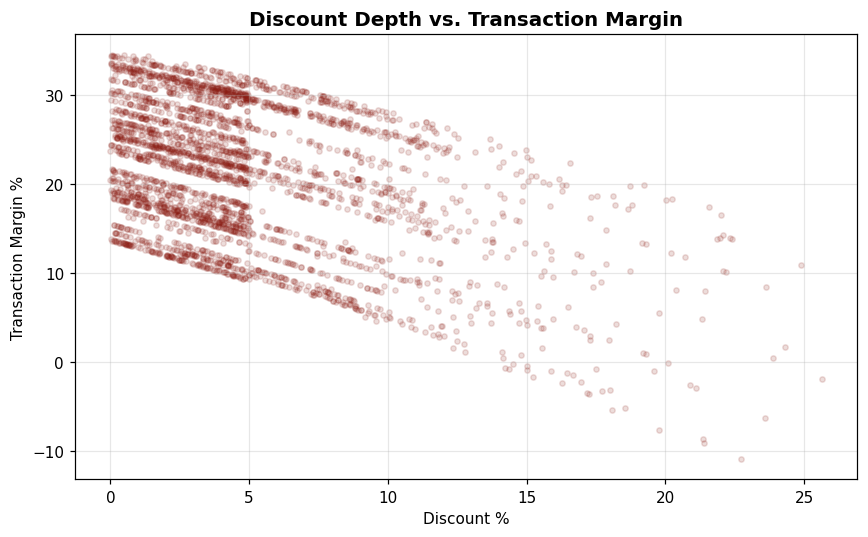

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
sample = df.sample(min(3000, len(df)), random_state=1)
ax.scatter(sample['Discount_Pct']*100, sample['Margin_Pct'], alpha=0.15, s=12, color='#8c1c13')
ax.set_xlabel('Discount %')
ax.set_ylabel('Transaction Margin %')
ax.set_title('Discount Depth vs. Transaction Margin', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = df[['Discount_Pct','Margin_Pct']].corr().iloc[0,1]
print(f"Correlation between discount depth and margin: {corr:.2f}")


## 7.5 Profitability by Discount Governance Scenario (What-If)

In [ ]:
# Simulate capping all discounts above 20% down to 20%, holding volume constant
df_sim = df.copy()
capped_discount_pct = df_sim['Discount_Pct'].clip(upper=0.20)
gross = df_sim['Unit_Price'] * df_sim['Quantity_Sold']
sim_sales_amount = gross * (1 - capped_discount_pct)
sim_profit = sim_sales_amount - df_sim['Cost_Amount']

current_profit = df_sim['Profit'].sum()
simulated_profit = sim_profit.sum()
uplift = simulated_profit - current_profit

print(f"Current total profit (period)         : NGN {current_profit:,.0f}")
print(f"Simulated profit with 20% discount cap : NGN {simulated_profit:,.0f}")
print(f"Estimated profitability uplift         : NGN {uplift:,.0f}")
print("\n(This is a simplified, volume-held-constant simulation for directional")
print(" sizing only — see the Business Consulting Report for the caveated,")
print(" board-ready version of this figure.)")


Current total profit (period)         : NGN 227,168,641
Simulated profit with 20% discount cap : NGN 227,392,468
Estimated profitability uplift         : NGN 223,827

(This is a simplified, volume-held-constant simulation for directional
 sizing only — see the Business Consulting Report for the caveated,
 board-ready version of this figure.)


## 7.6 Profitability Takeaways

1. Category and region both have a measurable, independent effect on margin
   — margin is not simply a function of discounting, but discount depth is
   the single strongest lever management can act on quickly.
2. The discount-cap simulation suggests a **material, though approximate**,
   profitability recovery opportunity purely from tightening discount
   governance — this directional figure is refined and formally caveated
   as a "Simulated Business Impact" figure in the final report.
3. Category × region combinations with the weakest margins should be
   prioritized for pricing review ahead of the next planning cycle.

**Next:** Notebook 8 — Business Recommendations.
